<a href="https://colab.research.google.com/github/ayaz-ali-36/Machine-Learning/blob/main/desisionTree/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [21]:
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df  = pd.read_csv(url)  # Q1: what goes here?

print("Shape:", df.shape)

Shape: (303, 14)


In [23]:
cat_cols  = ['cp', 'restecg', 'slope', 'thal']
df_model  = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [29]:
X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 242
Test size:  61


In [31]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_acc = baseline.score(X_test, y_test)

print(f"Baseline accuracy: {baseline_acc:.3f}")

Baseline accuracy: 0.541


In [32]:


depths = [1, 3, 5, None]

train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    print(f"Depth {str(depth):<5}: "
          f"Train={train_acc:.3f}, "
          f"Test={test_acc:.3f}")

Depth 1    : Train=0.781, Test=0.705
Depth 3    : Train=0.860, Test=0.705
Depth 5    : Train=0.934, Test=0.770
Depth None : Train=1.000, Test=0.754


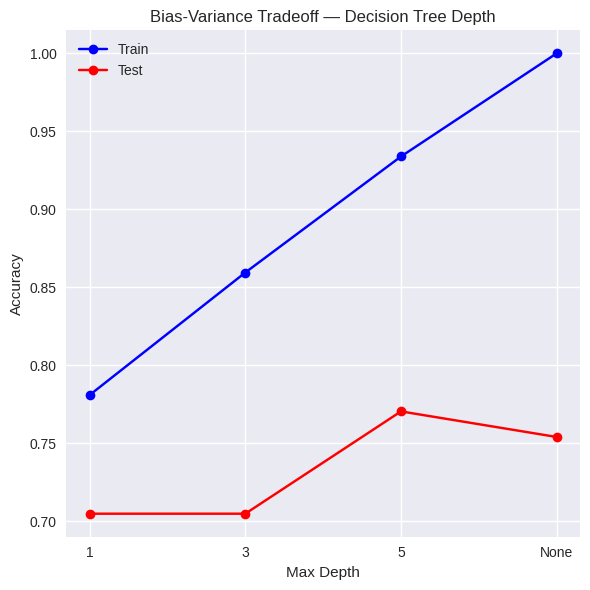

In [35]:
plt.figure(figsize=(6, 6))

depth_labels = ['1', '3', '5', 'None']

plt.plot(depth_labels, train_scores,
         'b-o', label='Train')

plt.plot(depth_labels, test_scores,
         'r-o', label='Test')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')

plt.title('Bias-Variance Tradeoff — Decision Tree Depth')

plt.legend()

plt.tight_layout()

plt.show()

In [36]:
best_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)

best_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [37]:
cv_scores = cross_val_score(
    best_tree,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(f"\nCV Scores: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.3f}")
print(f"Std:  {cv_scores.std():.3f}")


CV Scores: [0.755 0.796 0.792 0.833 0.833]
Mean: 0.802
Std:  0.029


In [38]:
y_pred = best_tree.predict(X_test)

print(f"\nBaseline:  {baseline_acc:.3f}")
print(f"Our Tree:  {best_tree.score(X_test, y_test):.3f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Disease', 'Disease']
))


Baseline:  0.541
Our Tree:  0.705

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.78      0.50      0.61        28
     Disease       0.67      0.88      0.76        33

    accuracy                           0.70        61
   macro avg       0.73      0.69      0.69        61
weighted avg       0.72      0.70      0.69        61



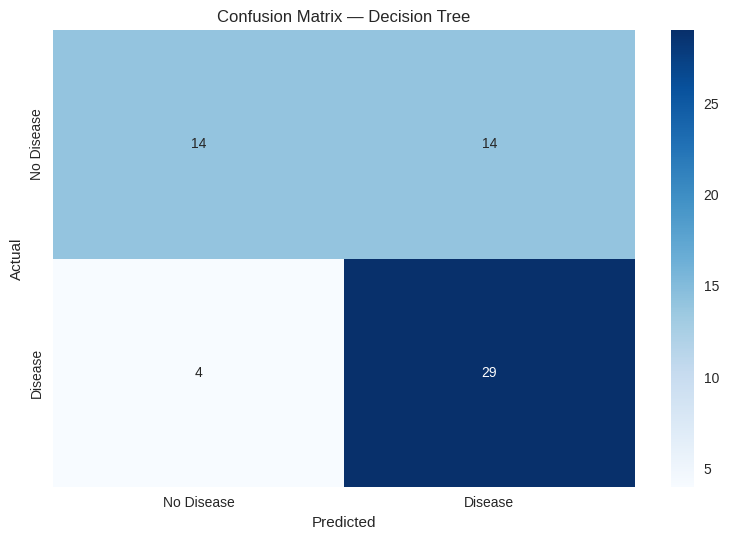

In [39]:
cm = confusion_matrix(y_test, y_pred)  # Q38, Q39
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

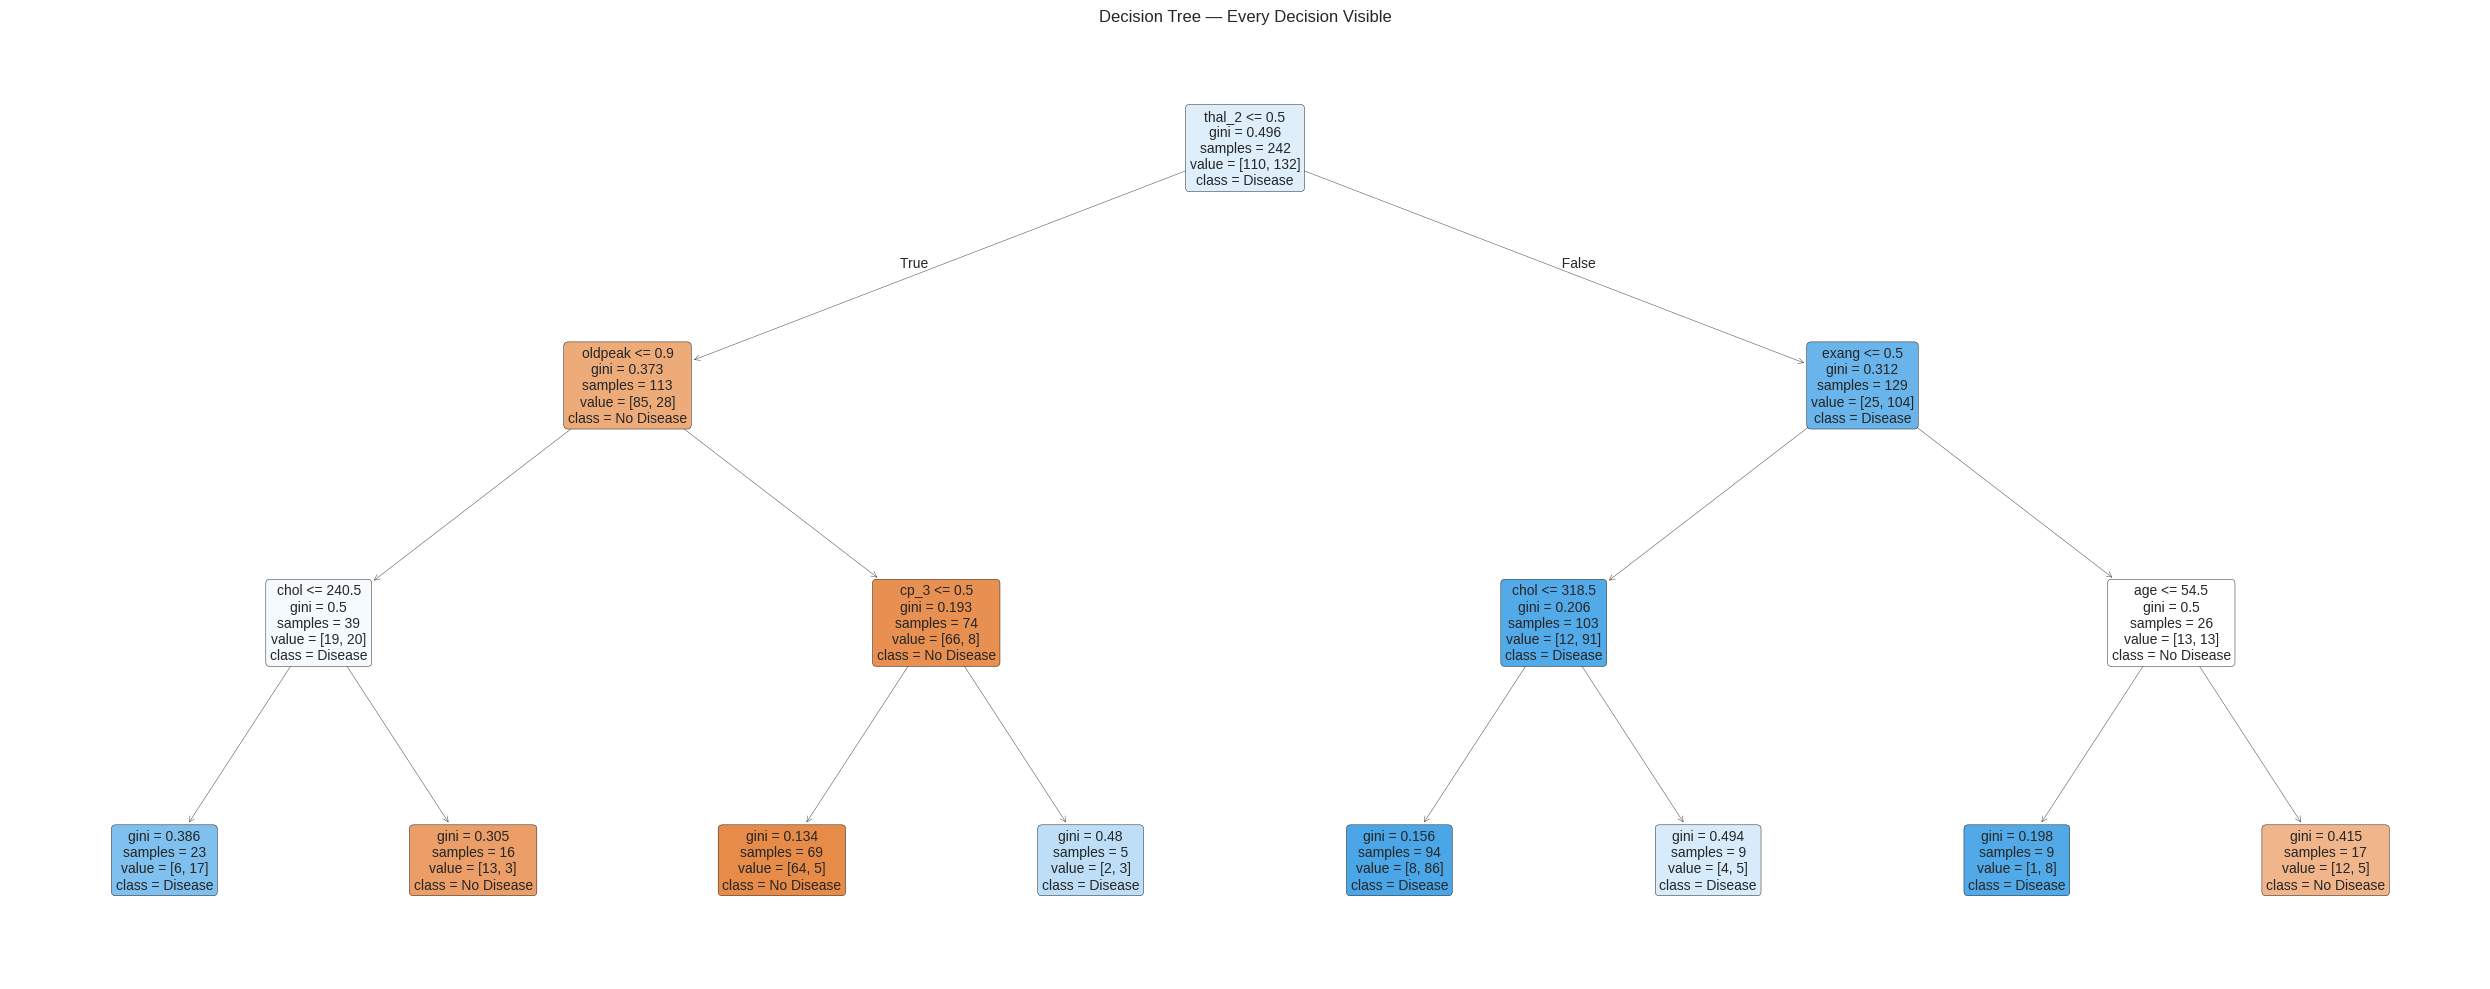

In [40]:
plt.figure(figsize=(25, 10))

plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Decision Tree — Every Decision Visible')
plt.tight_layout()
plt.show()

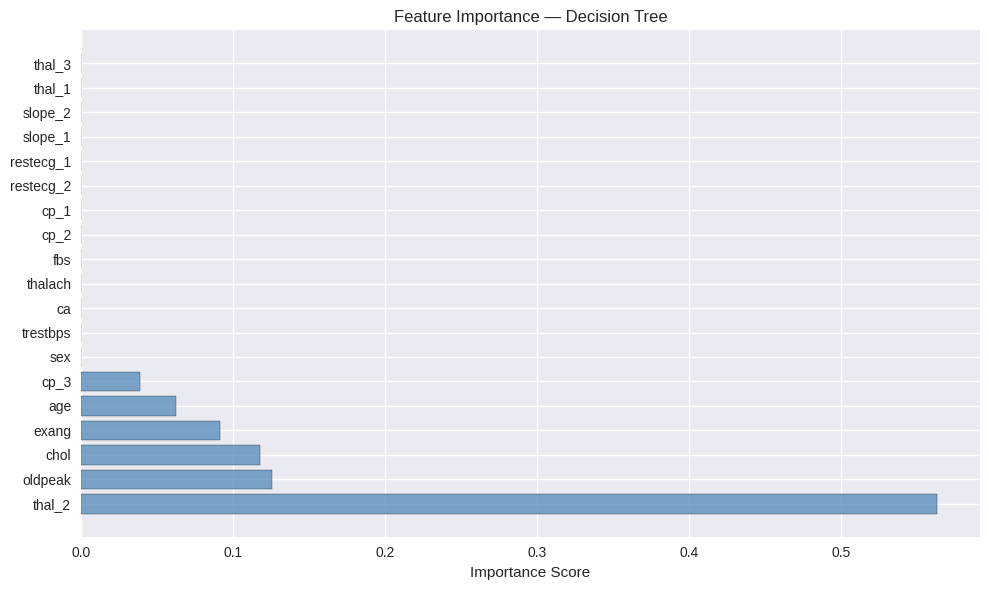


Top 5 most important features:
    Feature  Importance
17   thal_2    0.563541
7   oldpeak    0.125508
3      chol    0.117967
6     exang    0.091601
0       age    0.062457


In [43]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'],
         feat_imp['Importance'],
         color='steelblue',
         edgecolor='black',
         alpha=0.7)

plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head(5)[['Feature', 'Importance']])